In [ ]:
# @title APPLICATION OF METHODS ON RECORDING

import os
import numpy as np
import matplotlib.pyplot as plt
!pip install neo
!pip install torch_xla -f https://storage.googleapis.com/tpu-pytorch/wheels/tpuvm/torch_xla-1.13-cp310-cp310-linux_x86_64.whl
from neo.io import NeuralynxIO
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.signal import butter, filtfilt, welch
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import cv2
from scipy.stats import kurtosis, skew
from google.colab import drive
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score
import joblib
import seaborn as sns
import pandas as pd
import torch_xla
import torch_xla.core.xla_model as xm
from sklearn.metrics import davies_bouldin_score
from sklearn.manifold import TSNE
from scipy.stats import ttest_ind, f_oneway
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from google.colab import files



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 655.1/655.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.4/102.4 kB 4.9 MB/s eta 0:00:00
Looking in links: https://storage.googleapis.com/tpu-pytorch/wheels/tpuvm/torch_xla-1.13-cp310-cp310-linux_x86_64.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 MB 24.3 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/torch_xla/__init__.py:253: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


In [ ]:
# @title Parameter Setup and Waveform filtering

# Set device to TPU
# device = xm.xla_device()


# I use Google Drive to upload the dataset, please specify the path of the
# location you are going dowload the zip file in, in the directory_path.
drive.mount('/content/drive') # in case you use Google Drive for uploads.
directory_path = "/content/drive/MyDrive/Contest/Set1"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Parameters
sampling_rate = 32000  # Based on Steinmetz et al.
lowcut = 300
highcut = 3000
threshold_factor = 3.0
window_size = 64
directory_path = "/content/drive/MyDrive/Contest/Set1"

# Bandpass filter function
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low, high = lowcut / nyquist, highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Spike detection function
def detect_spikes(filtered_data, threshold_factor):
    threshold = threshold_factor * np.std(filtered_data)
    spike_indices = np.where(filtered_data > threshold)[0]
    return spike_indices

# Waveform feature extraction function
def extract_waveform_features(signal, spike_indices, window=64):
    features = []
    for idx in spike_indices:
        if idx - window >= 0 and idx + window < len(signal):
            waveform = signal[idx - window: idx + window]
            f, Pxx = welch(waveform, fs=sampling_rate, nperseg=96)
            max_psd = np.max(Pxx)
            mean_waveform = np.mean(waveform)
            std_waveform = np.std(waveform)
            snr = mean_waveform / std_waveform if std_waveform != 0 else 0
            peak_to_peak_amplitude = np.ptp(waveform)
            skewness = skew(waveform)
            kurt = kurtosis(waveform)
            energy = np.sum(waveform ** 2)
            features.append([max_psd, mean_waveform, std_waveform, skewness, kurt, snr, peak_to_peak_amplitude, energy])
    return features

# Load files and process recordings
waveform_features = []
ncs_files = [f for f in os.listdir(directory_path) if f.endswith(".Ncs")]

for filename in ncs_files:
    reader = NeuralynxIO(dirname=directory_path, include_filenames=[filename])
    seg = reader.read_segment()
    raw_data = np.array(seg.analogsignals[0]).flatten()

    # Apply bandpass filter and detect spikes
    filtered_data = bandpass_filter(raw_data, lowcut, highcut, sampling_rate)
    spike_indices = detect_spikes(filtered_data, threshold_factor)

    # Extract waveform features and add to dataset
    features = extract_waveform_features(filtered_data, spike_indices)
    if len(features) > 0:
        waveform_features.extend(features)

# Convert to numpy array and handle NaNs
waveform_features = np.array(waveform_features)
waveform_features = np.nan_to_num(waveform_features)

# Standardize the features
scaler = StandardScaler()
waveform_features = scaler.fit_transform(waveform_features)

### Specify your location
joblib.dump(waveform_features, '/content/drive/MyDrive/Contest/saved_waveform_features.pkl')



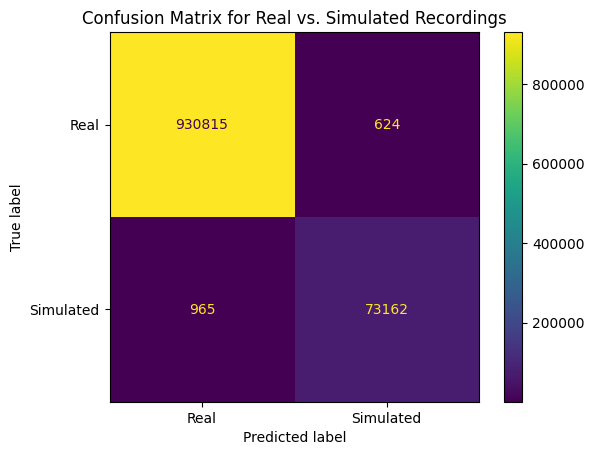

Model training and classification completed.
Validation Accuracy (RandomForest): 1.00
Classification Report (RandomForest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    931439
           1       0.99      0.99      0.99     74127

    accuracy                           1.00   1005566
   macro avg       1.00      0.99      0.99   1005566
weighted avg       1.00      1.00      1.00   1005566



NameError: name 'filtered_data' is not defined

In [ ]:
# @title GMM
### Specify your location
waveform_features = joblib.load('/content/drive/MyDrive/Contest/saved_waveform_features.pkl')

# Initial clustering with GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(waveform_features)

# Convert GMM labels to binary: 0 -> Simulated, 1 -> Real
gmm_labels = np.where(gmm_labels == 0, 1, 0)  # Cluster 0 -> 1 (Real), Cluster 1 -> 0 (Simulated)

# Step 1: Correct Label Mapping - Define Function
def map_to_binary(labels):
    """Maps labels to binary classes 0 and 1, where 0 is Simulated and 1 is Real."""
    return np.where(labels == 1, 1, 0)

# Apply binary mapping to ensure consistency across all label arrays
gmm_labels = map_to_binary(gmm_labels)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(waveform_features, gmm_labels, test_size=0.2, random_state=42)

# Apply binary mapping to train and test labels
y_train = map_to_binary(y_train)
y_test = map_to_binary(y_test)


# # @title Train a Random Forest Classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
# Predictions on Test Data
predictions = classifier.predict(X_test)
predictions = map_to_binary(predictions)  # Ensure predictions align with binary labels if needed
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Simulated'])
disp.plot(cmap='viridis')
plt.title('Confusion Matrix for Real vs. Simulated Recordings')
plt.show()


print("Model training and classification completed.")

# Validation Accuracy and Classification Report
accuracy = accuracy_score(y_test, predictions)
print(f"Validation Accuracy (RandomForest): {accuracy:.2f}")
print("Classification Report (RandomForest):")
print(classification_report(y_test, predictions))

# Train CNN + LSTM Model with Waveform-Level Features
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=100, shuffle=False)

# Save relevant datasets and labels
### Specify your location
joblib.dump(classifier, '/content/drive/MyDrive/Contest/saved_random_forest.pkl')
joblib.dump(X_train, '/content/drive/MyDrive/Contest/saved_X_train.pkl')
joblib.dump(X_test, '/content/drive/MyDrive/Contest/saved_X_test.pkl')
joblib.dump(y_train, '/content/drive/MyDrive/Contest/saved_y_train.pkl')
joblib.dump(y_test, '/content/drive/MyDrive/Contest/saved_y_test.pkl')
joblib.dump(predictions, '/content/drive/MyDrive/Contest/saved_predictions.pkl')
joblib.dump(gmm_labels, '/content/drive/MyDrive/Contest/saved_gmm_labels.pkl')
# joblib.dump(filtered_data, '/content/drive/MyDrive/Contest/saved_filtered_data.pkl')


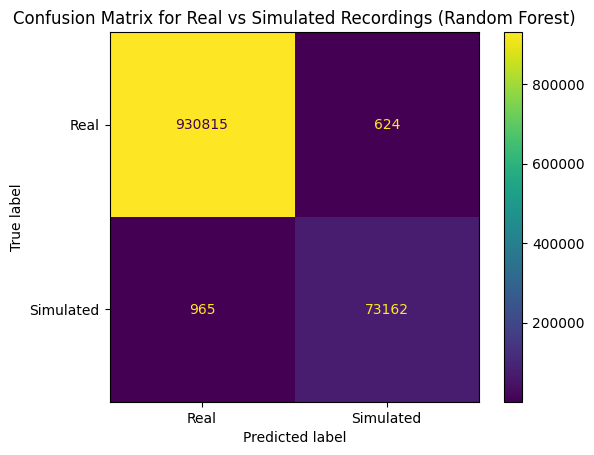

Random Forest model training completed.


In [ ]:
# @title Predictions and evaluation

# predictions = classifier.predict(X_test)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Simulated'])
disp.plot(cmap='viridis')
plt.title('Confusion Matrix for Real vs Simulated Recordings (Random Forest)')
plt.show()

# Save the model and scaler for future use
### Specify your location
joblib.dump(classifier, '/content/drive/MyDrive/Contest/classifier.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Contest/scaler.pkl')
print("Random Forest model training completed.")

In [ ]:
# Davies-Boulding score

db_score = davies_bouldin_score(waveform_features, gmm_labels)
print(f'Davies-Bouldin Index: {db_score}')


NameError: name 'waveform_features' is not defined

In [ ]:
# @title Variable loading for testing
### The below variable paths should be adjusted according to the location you have saved these variables above.

# Load
scaler = joblib.load('/content/drive/MyDrive/Contest/scaler.pkl')
waveform_features = joblib.load('/content/drive/MyDrive/Contest/saved_waveform_features.pkl')

# ncs_files = joblib.load('/content/drive/MyDrive/Contest/ncs_files.csv')
classifier = joblib.load('/content/drive/MyDrive/Contest/saved_random_forest.pkl')
X_train = joblib.load('/content/drive/MyDrive/Contest/saved_X_train.pkl')
X_test = joblib.load('/content/drive/MyDrive/Contest/saved_X_test.pkl')
y_train = joblib.load('/content/drive/MyDrive/Contest/saved_y_train')
y_test = joblib.load('/content/drive/MyDrive/Contest/saved_y_pred.pkl')
filtered_data = joblib.load('/content/drive/MyDrive/Contest/saved_filtered_data.pkl')

predictions = joblib.load('/content/drive/MyDrive/Contest/saved_predictions.pkl')
gmm_labels_inverted = joblib.load('/content/drive/MyDrive/Contest/saved_gmm_labels.pkl')
gmm_labels = joblib.load('/content/drive/MyDrive/Contest/saved_gmm_labels.pkl')
recording_labels = joblib.load('/content/drive/MyDrive/Contest/saved_recording_labels.pkl')


Epoch 1/100, Loss: 0.0304
Epoch 2/100, Loss: 0.0203
Epoch 3/100, Loss: 0.0179
Epoch 4/100, Loss: 0.0149
Epoch 5/100, Loss: 0.0124
Epoch 6/100, Loss: 0.0108
Epoch 7/100, Loss: 0.0099
Epoch 8/100, Loss: 0.0093
Epoch 9/100, Loss: 0.0087
Epoch 10/100, Loss: 0.0083
Epoch 11/100, Loss: 0.0080
Epoch 12/100, Loss: 0.0078
Epoch 13/100, Loss: 0.0075
Epoch 14/100, Loss: 0.0074
Epoch 15/100, Loss: 0.0072
Epoch 16/100, Loss: 0.0071
Epoch 17/100, Loss: 0.0070
Epoch 18/100, Loss: 0.0069
Epoch 19/100, Loss: 0.0068
Epoch 20/100, Loss: 0.0066
Epoch 21/100, Loss: 0.0066
Epoch 22/100, Loss: 0.0065
Epoch 23/100, Loss: 0.0064
Epoch 24/100, Loss: 0.0063
Epoch 25/100, Loss: 0.0063
Epoch 26/100, Loss: 0.0062
Epoch 27/100, Loss: 0.0061
Epoch 28/100, Loss: 0.0061
Epoch 29/100, Loss: 0.0060
Epoch 30/100, Loss: 0.0060
Epoch 31/100, Loss: 0.0059
Epoch 32/100, Loss: 0.0059
Epoch 33/100, Loss: 0.0058
Epoch 34/100, Loss: 0.0058
Epoch 35/100, Loss: 0.0058
Epoch 36/100, Loss: 0.0057
Epoch 37/100, Loss: 0.0057
Epoch 38/1

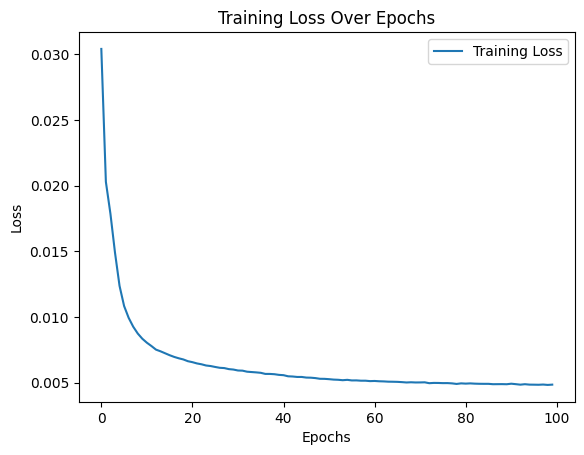

In [ ]:
# @title SSM

# Define CNN + LSTM model for waveform-level features
class SpikeSortingModel(nn.Module):
    def __init__(self, input_dim, n_clusters):
        super(SpikeSortingModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, n_clusters)

    def forward(self, x):
        x = torch.relu(self.conv1(x.unsqueeze(1)))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        _, (hn, _) = self.lstm(x)
        x = self.fc(hn[-1])
        return x

# Training parameters
n_epochs = 100
batch_size = 100

# Prepare data loaders
# train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
# val_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Instantiate and train the model
model = SpikeSortingModel(input_dim=X_train.shape[1], n_clusters=2)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0001)

# Initialize lists to store loss values
training_losses = []

# Update training loop to store loss per epoch
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    # Calculate average loss per epoch and store
    avg_loss = running_loss / len(train_loader)
    training_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

# Plot training loss over epochs
plt.plot(training_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Specify your location
joblib.dump(running_loss, '/content/drive/MyDrive/Contest/saved_train_losses.pkl')
joblib.dump(model, '/content/drive/MyDrive/Contest/saved_cnn_lstm_model.pkl')
running_loss = joblib.load('/content/drive/MyDrive/Contest/saved_train_losses.pkl')
model = joblib.load('/content/drive/MyDrive/Contest/saved_cnn_lstm_model.pkl')


In [ ]:

# Function to map any unintended labels to binary values
def map_to_binary(labels):
    # Ensure only classes 0 and 1 remain, where 0 is Simulated and 1 is Real
    return np.where(labels == 1, 1, 0)


Validation Accuracy (CNN+LSTM): 1.00
Classification Report (CNN+LSTM):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00    931439
   Simulated       0.99      0.98      0.99     74127

    accuracy                           1.00   1005566
   macro avg       1.00      0.99      0.99   1005566
weighted avg       1.00      1.00      1.00   1005566



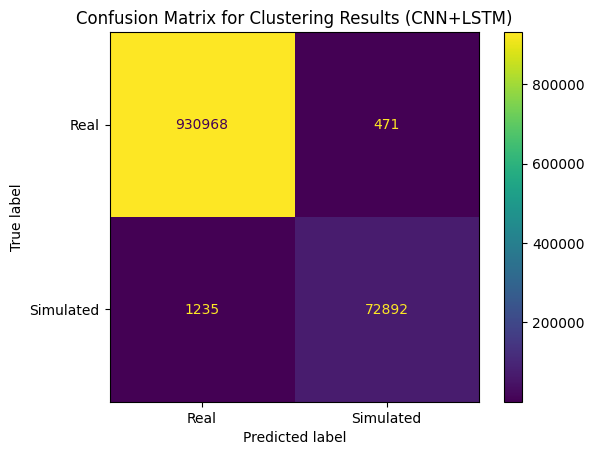

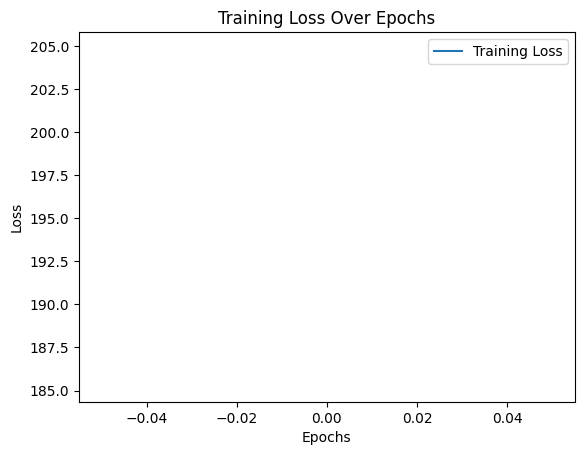

['/content/drive/MyDrive/Contest/saved_recording_labels.pkl']

In [ ]:
# @title Evaluation

# Validate the model and collect predictions
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in val_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Step 1: Correct Label Mapping for Evaluation
all_labels = map_to_binary(np.array(all_labels))
all_preds = map_to_binary(np.array(all_preds))

# Generate evaluation metrics
accuracy = correct / total
print(f"Validation Accuracy (CNN+LSTM): {accuracy:.2f}")
print("Classification Report (CNN+LSTM):")
print(classification_report(all_labels, all_preds, target_names=['Real', 'Simulated']))

# Display Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Simulated'])
disp.plot(cmap='viridis')
plt.title('Confusion Matrix for Clustering Results (CNN+LSTM)')
plt.show()

# Load saved training losses if available
### Specify your location
train_losses = joblib.load('/content/drive/MyDrive/Contest/saved_train_losses.pkl')

# Plot training loss if available
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Specify your location
joblib.dump(all_preds, '/content/drive/MyDrive/Contest/saved_y_pred.pkl')
joblib.dump(all_labels, '/content/drive/MyDrive/Contest/saved_recording_labels.pkl')


Original GMM label distribution: {0: 4657765, 1: 370063}
CNN+LSTM model prediction distribution: {0: 930011, 1: 75555}


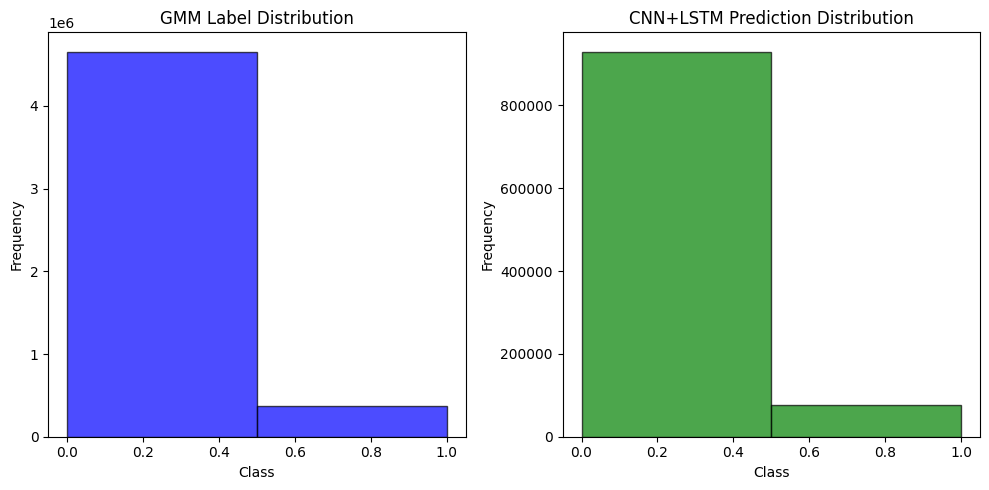

In [ ]:
# Check the distribution of original GMM labels
unique, counts = np.unique(gmm_labels, return_counts=True)
print(f"Original GMM label distribution: {dict(zip(unique, counts))}")

# Check distribution in CNN+LSTM model predictions
unique, counts = np.unique(all_preds, return_counts=True)
print(f"CNN+LSTM model prediction distribution: {dict(zip(unique, counts))}")

# Visualization of GMM and NN Predicted Class Distributions
plt.figure(figsize=(10, 5))

# GMM Labels Distribution
plt.subplot(1, 2, 1)
plt.hist(gmm_labels, bins=2, alpha=0.7, color='blue', edgecolor='black')
plt.title('GMM Label Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')

# NN Prediction Distribution
plt.subplot(1, 2, 2)
plt.hist(all_preds, bins=2, alpha=0.7, color='green', edgecolor='black')
plt.title('CNN+LSTM Prediction Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Classification Report for CNN+LSTM Model:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00    931439
   Simulated       0.98      0.99      0.98     74127

    accuracy                           1.00   1005566
   macro avg       0.99      1.00      0.99   1005566
weighted avg       1.00      1.00      1.00   1005566



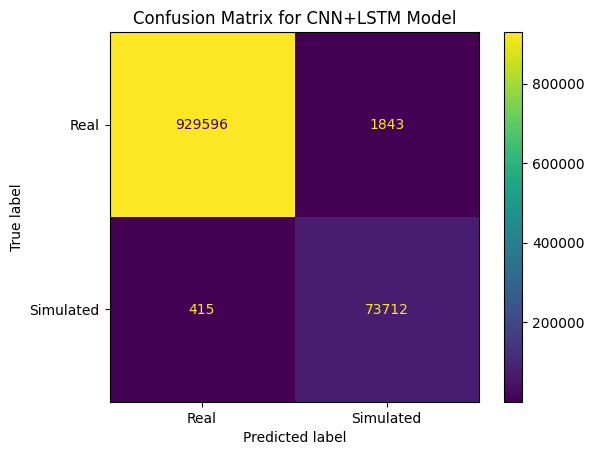

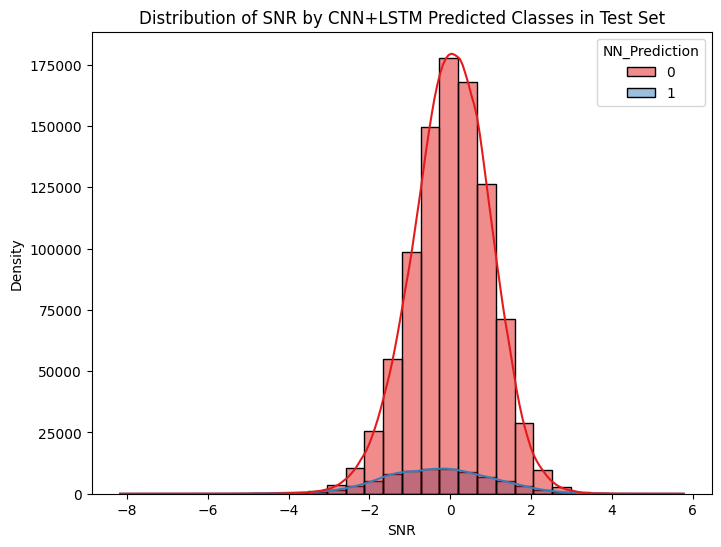

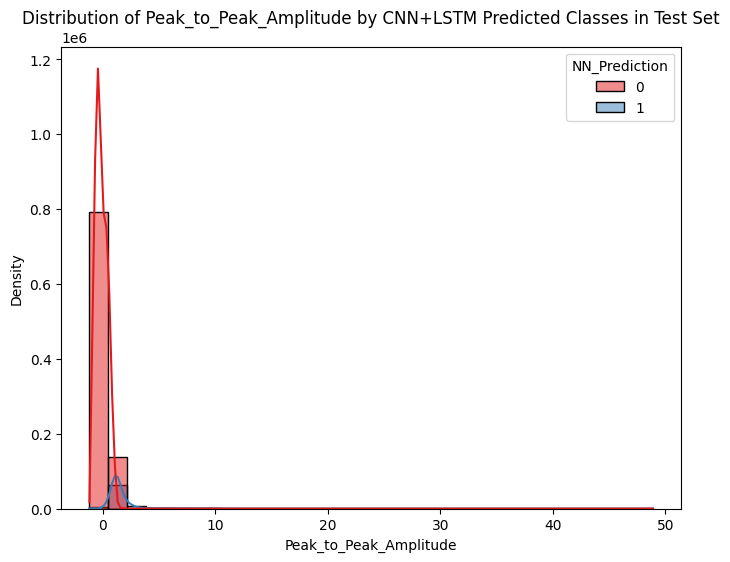

In [ ]:

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Display the classification report for the CNN+LSTM model
print("Classification Report for CNN+LSTM Model:")
print(classification_report(all_labels, all_preds, target_names=['Real', 'Simulated']))

# Display confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Simulated'])
disp.plot(cmap='viridis')
plt.title('Confusion Matrix for CNN+LSTM Model')
plt.show()

import seaborn as sns
import pandas as pd

# Convert test features to DataFrame and add predictions
test_features_df = pd.DataFrame(X_test, columns=['Max_PSD', 'Mean', 'Std', 'Skewness', 'Kurtosis', 'SNR', 'Peak_to_Peak_Amplitude', 'Energy'])
test_features_df['NN_Prediction'] = all_preds

# Plot SNR and Peak-to-Peak Amplitude distributions based on predictions in the test set
for feature in ['SNR', 'Peak_to_Peak_Amplitude']:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=test_features_df, x=feature, hue='NN_Prediction', kde=True, bins=30, palette="Set1")
    plt.title(f"Distribution of {feature} by CNN+LSTM Predicted Classes in Test Set")
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()



In [ ]:
# @title Load output

### Specify your location
classifier = joblib.load('/content/drive/MyDrive/Contest/saved_random_forest.pkl')


# Assuming you have already defined the model class `SpikeSortingModel`
model = SpikeSortingModel(input_dim=waveform_features.shape[1], n_clusters=2)
model.load_state_dict(torch.load('/content/drive/MyDrive/Contest/saved_neural_network.pth'))
model.eval()  # Set model to evaluation mode

# all_preds = joblib.load('/content/drive/MyDrive/Contest/saved_y_pred.pkl')
# all_labels = joblib.load('/content/drive/MyDrive/Contest/saved_recording_labels.pkl')

<ipython-input-16-2486a426554f>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/Contest/saved_neural_network.pth'))

SpikeSortingModel(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

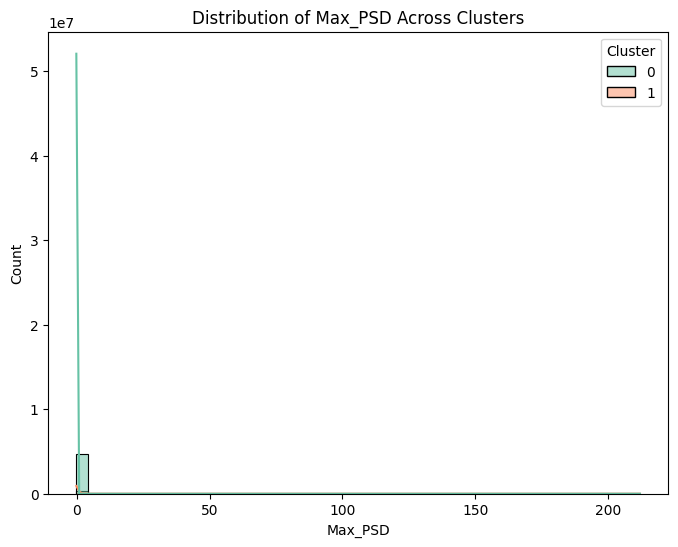

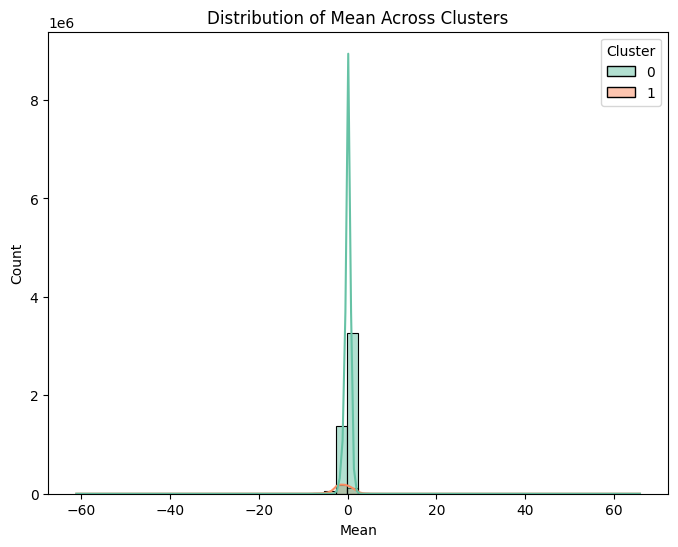

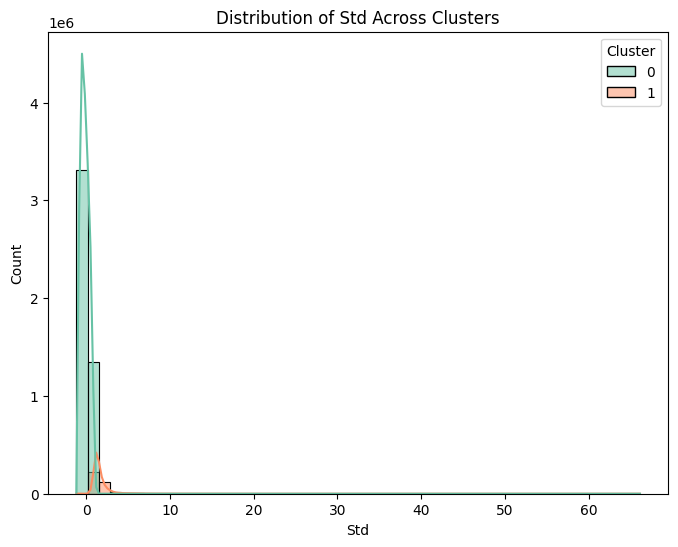

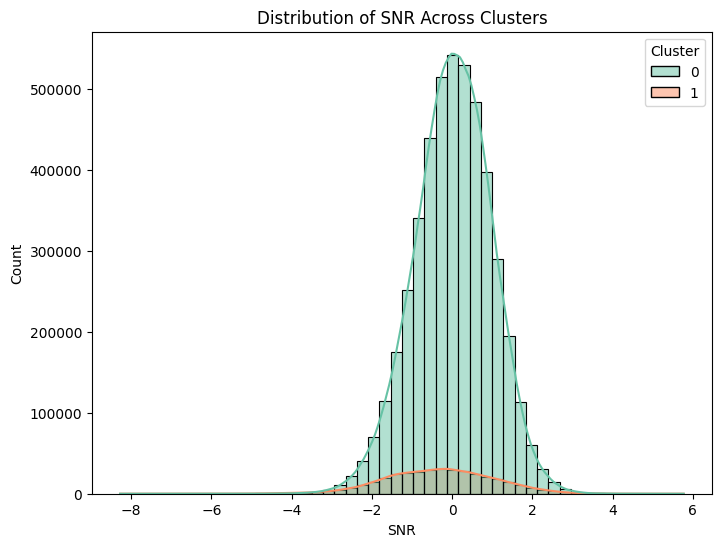

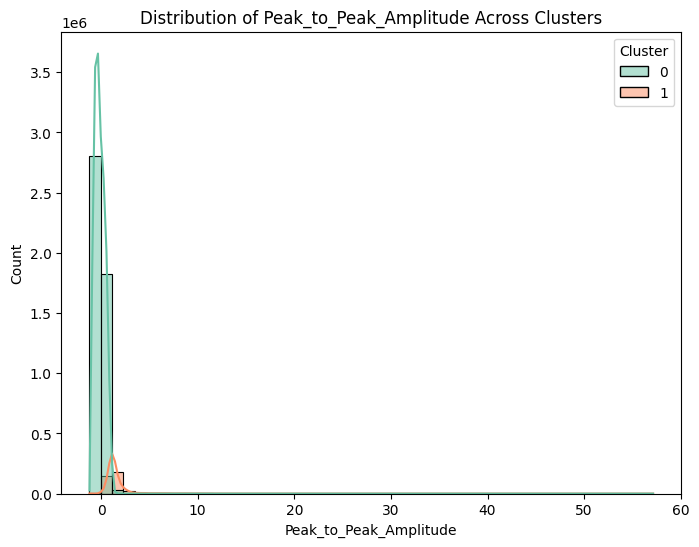

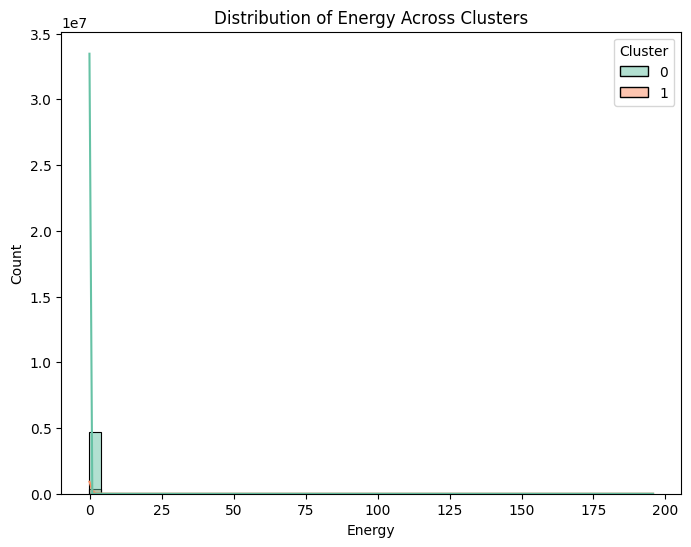

In [ ]:
# @title Further Analysis

import pandas as pd
# Combine the features and labels into a DataFrame for easier analysis
features_df = pd.DataFrame(waveform_features, columns=['Max_PSD', 'Mean', 'Std', 'Skewness', 'Kurtosis', 'SNR', 'Peak_to_Peak_Amplitude', 'Energy'])
features_df['Cluster'] = gmm_labels  # Add cluster labels

# Plot the distributions of key features across clusters
for feature in ['Max_PSD', 'Mean', 'Std', 'SNR', 'Peak_to_Peak_Amplitude', 'Energy']:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=features_df, x=feature, hue='Cluster', kde=True, palette="Set2", bins=50)
    plt.title(f"Distribution of {feature} Across Clusters")
    plt.show()


Correlation matrix for Cluster 0:
                         Max_PSD      Mean       Std  Skewness  Kurtosis  \
Max_PSD                 1.000000 -0.198393  0.833554 -0.139759  0.121645   
Mean                   -0.198393  1.000000 -0.225203 -0.299465  0.021927   
Std                     0.833554 -0.225203  1.000000 -0.151294  0.103162   
Skewness               -0.139759 -0.299465 -0.151294  1.000000 -0.055644   
Kurtosis                0.121645  0.021927  0.103162 -0.055644  1.000000   
SNR                     0.025911  0.894462  0.042870 -0.316483  0.014640   
Peak_to_Peak_Amplitude  0.793907 -0.187751  0.965940 -0.184768  0.270119   
Energy                  0.850980 -0.233870  0.978760 -0.127124  0.089368   
Cluster                      NaN       NaN       NaN       NaN       NaN   

                             SNR  Peak_to_Peak_Amplitude    Energy  Cluster  
Max_PSD                 0.025911                0.793907  0.850980      NaN  
Mean                    0.894462               -0

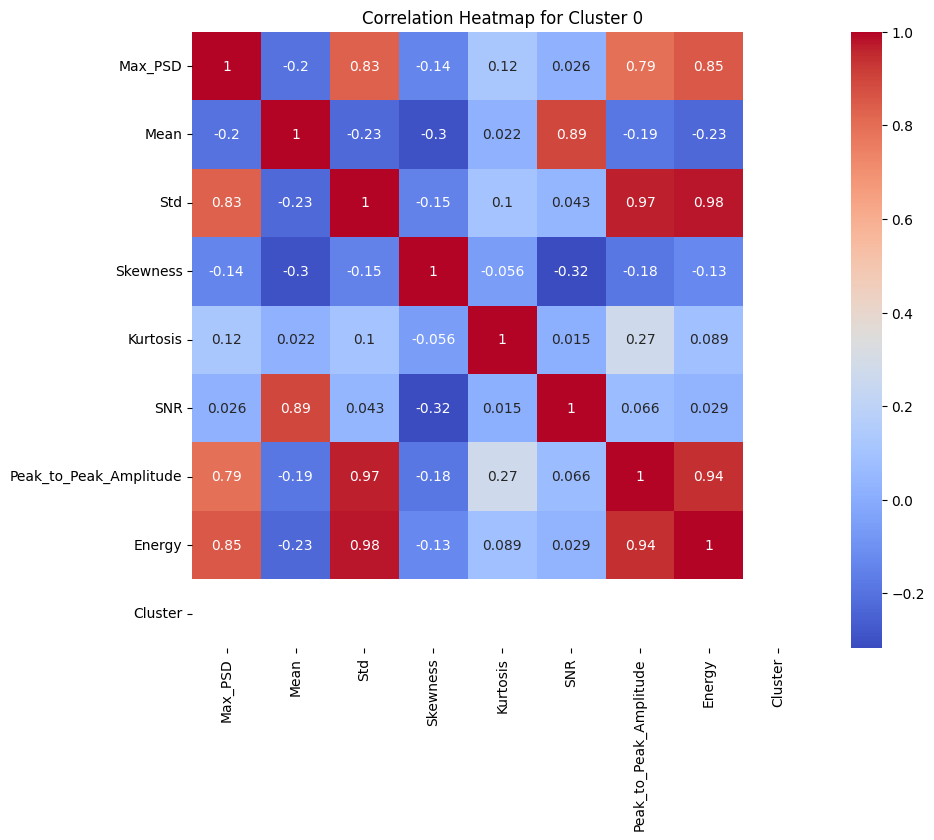

Correlation matrix for Cluster 1:
                         Max_PSD      Mean       Std  Skewness  Kurtosis  \
Max_PSD                 1.000000 -0.022524  0.763115 -0.071860  0.003969   
Mean                   -0.022524  1.000000 -0.156218 -0.070098 -0.038694   
Std                     0.763115 -0.156218  1.000000 -0.157388  0.076892   
Skewness               -0.071860 -0.070098 -0.157388  1.000000  0.220342   
Kurtosis                0.003969 -0.038694  0.076892  0.220342  1.000000   
SNR                     0.039443  0.773438  0.052144 -0.204467 -0.015927   
Peak_to_Peak_Amplitude  0.701504 -0.146661  0.974889 -0.160308  0.198157   
Energy                  0.870840 -0.062342  0.875666 -0.106072  0.037616   
Cluster                      NaN       NaN       NaN       NaN       NaN   

                             SNR  Peak_to_Peak_Amplitude    Energy  Cluster  
Max_PSD                 0.039443                0.701504  0.870840      NaN  
Mean                    0.773438               -0

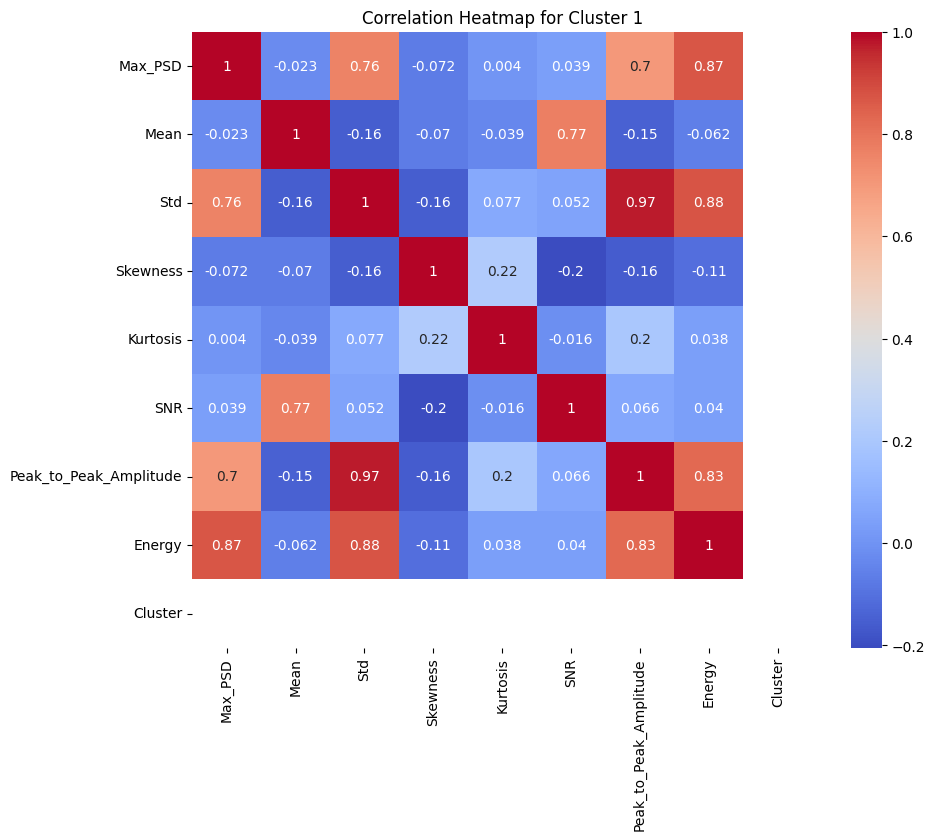

In [ ]:
# Compute correlation matrix for each cluster
for cluster in [0, 1]:
    print(f"Correlation matrix for Cluster {cluster}:")
    cluster_data = features_df[features_df['Cluster'] == cluster]
    correlation_matrix = cluster_data.corr()
    print(correlation_matrix)

    # Plot heatmap of correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title(f"Correlation Heatmap for Cluster {cluster}")
    plt.show()


In [ ]:
# @title (optional) TSE

# # Reduce features to 2D using t-SNE for visualization
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# tsne_results = tsne.fit_transform(waveform_features)

# # Plot the t-SNE results with cluster labels
# plt.figure(figsize=(8, 6))
# sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=gmm_labels, palette='Set1', s=60)
# plt.title("t-SNE Visualization of GMM Clusters")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.show()


<ipython-input-22-f9e39caa4fad>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


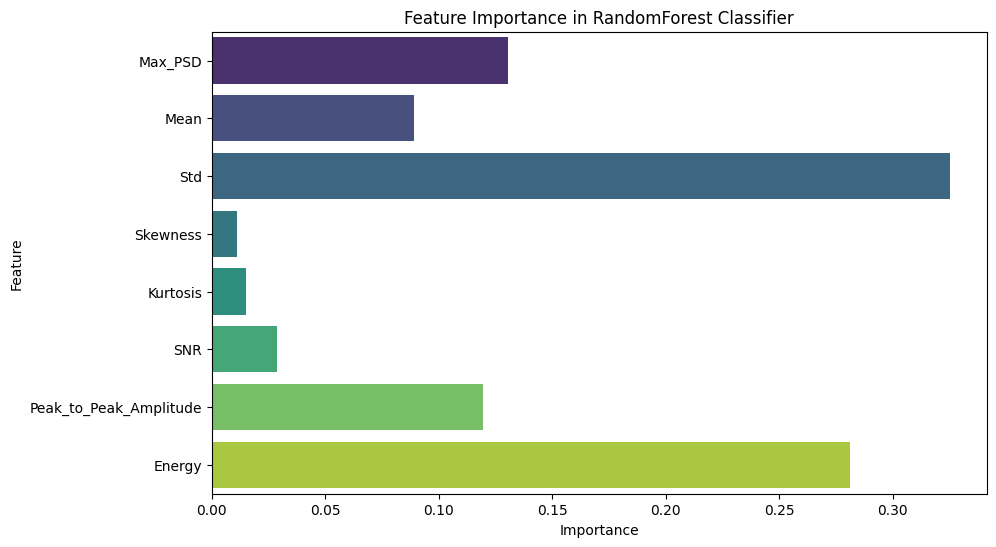

Max_PSD: 0.1305
Mean: 0.0891
Std: 0.3252
Skewness: 0.0109
Kurtosis: 0.0150
SNR: 0.0289
Peak_to_Peak_Amplitude: 0.1193
Energy: 0.2811


In [ ]:
# @title Feature Importances analysis

importances = classifier.feature_importances_
feature_names = ['Max_PSD', 'Mean', 'Std', 'Skewness', 'Kurtosis', 'SNR', 'Peak_to_Peak_Amplitude', 'Energy']

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Feature Importance in RandomForest Classifier")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Print out the feature importances
for feature, importance in zip(feature_names, importances):
    print(f"{feature}: {importance:.4f}")


In [ ]:
# @title ANOVA analysis
# Check the unique values in all_preds to see if both classes are present
unique_classes, counts = np.unique(all_preds, return_counts=True)
print(f"Class distribution in predictions (all_preds): {dict(zip(unique_classes, counts))}")


from scipy.stats import ttest_ind, f_oneway

# Ensure test_features aligns with all_preds by directly using indices from the test set
# This will avoid any mismatches
test_features = X_test  # Since X_test is derived from waveform_features and matches all_preds

# Verify dimensions match between `test_features` and `all_preds`
assert len(test_features) == len(all_preds), "Mismatch between test features and all_preds."

# Split features based on NN classifications in all_preds
features_real = test_features[np.array(all_preds) == 0]  # Class 0 predicted by NN as "Real"
features_simulated = test_features[np.array(all_preds) == 1]  # Class 1 predicted by NN as "Simulated"

# Define feature indices based on prior definitions
feature_index_snr = 5  # SNR
feature_index_peak_to_peak = 6  # Peak-to-Peak Amplitude

# Ensure alignment and check class distribution
print(f"Class distribution in `all_preds`: {np.unique(all_preds, return_counts=True)}")
from scipy.stats import ttest_ind, f_oneway

# Perform t-tests and ANOVA for SNR and Peak-to-Peak Amplitude
# Check if both classes are present in the predictions
if 0 in all_preds and 1 in all_preds:
    features_real = test_features[all_preds == 0]
    features_simulated = test_features[all_preds == 1]

    # Define feature indices for SNR and Peak-to-Peak Amplitude
    snr_real, snr_simulated = features_real[:, 5], features_simulated[:, 5]
    ppa_real, ppa_simulated = features_real[:, 6], features_simulated[:, 6]

    # SNR t-test and ANOVA
    t_stat_snr, p_val_snr = ttest_ind(snr_real, snr_simulated, equal_var=False)
    print(f"T-test for SNR: t-stat={t_stat_snr:.4f}, p-value={p_val_snr:.4e}")
    anova_snr = f_oneway(snr_real, snr_simulated)
    print(f"ANOVA SNR: F={anova_snr.statistic:.4f}, p-value={anova_snr.pvalue:.4e}")

    # Peak-to-Peak Amplitude t-test and ANOVA
    t_stat_ppa, p_val_ppa = ttest_ind(ppa_real, ppa_simulated, equal_var=False)
    print(f"T-test for Peak-to-Peak Amplitude: t-stat={t_stat_ppa:.4f}, p-value={p_val_ppa:.4e}")
    anova_ppa = f_oneway(ppa_real, ppa_simulated)
    print(f"ANOVA Peak-to-Peak Amplitude: F={anova_ppa.statistic:.4f}, p-value={anova_ppa.pvalue:.4e}")
else:
    print("Only one class predicted, statistical analysis skipped.")


In [ ]:
# @title Cohen's d
# Function to calculate Cohen's d
def compute_cohens_d(group1, group2):
    mean_diff = np.mean(group1) - np.mean(group2)
    pooled_std = np.sqrt(((np.std(group1) ** 2) + (np.std(group2) ** 2)) / 2)
    cohens_d = mean_diff / pooled_std
    return cohens_d

# Cohen's d for SNR and Peak-to-Peak Amplitude based on NN classifications
d_snr = compute_cohens_d(snr_real, snr_simulated)
d_ppa = compute_cohens_d(ppa_real, ppa_simulated)

print(f"Cohen's d for SNR (NN Classification): {d_snr:.4f}")
print(f"Cohen's d for Peak-to-Peak Amplitude (NN Classification): {d_ppa:.4f}")


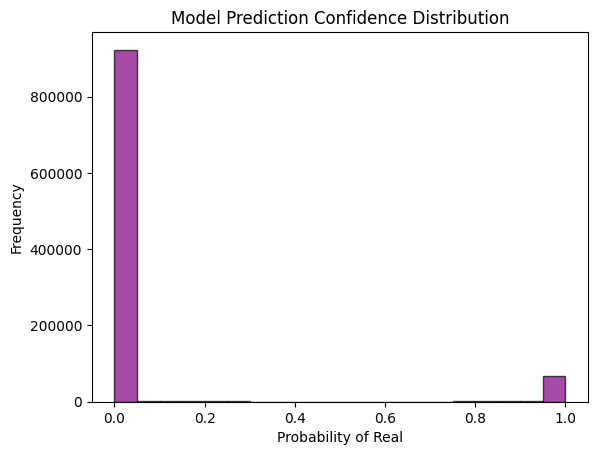

In [ ]:
# Calculate the model’s prediction confidence scores
probabilities = classifier.predict_proba(X_test)[:, 1]
plt.hist(probabilities, bins=20, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Probability of Real')
plt.ylabel('Frequency')
plt.title('Model Prediction Confidence Distribution')
plt.show()


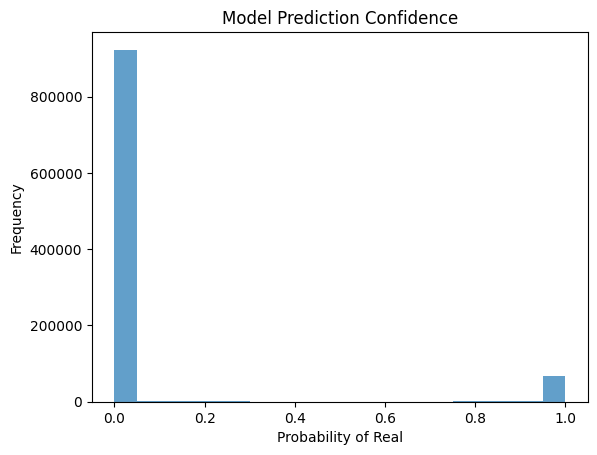

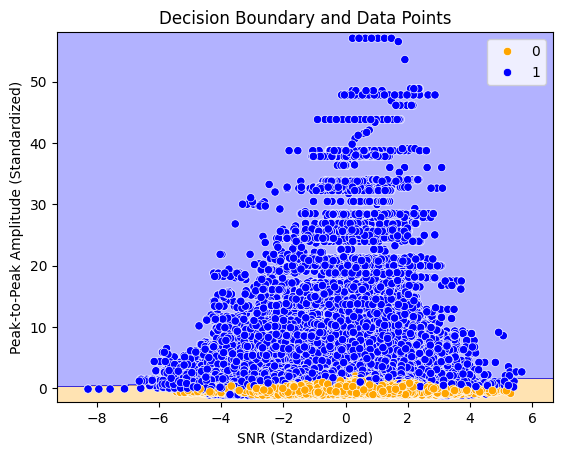

In [ ]:
# @title Model Confidence and Decision Boundaries

# Predict probabilities (if supported by model)
probabilities = classifier.predict_proba(X_test)[:, 1]  # Probability of "Real" (class 1) if using inverted labels

# Visualize confidence distribution
plt.hist(probabilities, bins=20, alpha=0.7, label='Real')
plt.title("Model Prediction Confidence")
plt.xlabel("Probability of Real")
plt.ylabel("Frequency")
plt.show()

# Use only the SNR and Peak-to-Peak Amplitude for training the visualization model
X_vis_train = X_train[:, [feature_index_snr, feature_index_peak_to_peak]]
y_vis_train = y_train

# Standardize the features for visualization
scaler_vis = StandardScaler()
X_vis_train = scaler_vis.fit_transform(X_vis_train)

# Train a logistic regression for visualization purposes
log_reg = LogisticRegression()
log_reg.fit(X_vis_train, y_vis_train)

# Determine the min and max values for each axis based on standardized data
x_min, x_max = X_vis_train[:, 0].min() - 1, X_vis_train[:, 0].max() + 1
y_min, y_max = X_vis_train[:, 1].min() - 1, X_vis_train[:, 1].max() + 1

# Generate the mesh grid for plotting the decision boundary
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['orange', 'blue']))
sns.scatterplot(x=X_vis_train[:, 0], y=X_vis_train[:, 1], hue=y_vis_train, palette=['orange', 'blue'])
plt.xlabel("SNR (Standardized)")
plt.ylabel("Peak-to-Peak Amplitude (Standardized)")
plt.title("Decision Boundary and Data Points")
plt.show()


5-Fold Cross-Validation Accuracy Scores: [0.9985083  0.99841184 0.99845759 0.99838598 0.9984009 ]
Mean Accuracy: 0.9984
Standard Deviation: 0.0000
Permutation Importances:
Max_PSD: 0.0538
Mean: 0.0090
Std: 0.0794
Skewness: 0.0014
Kurtosis: 0.0011
SNR: 0.0031
Peak_to_Peak_Amplitude: 0.0811
Energy: 0.1053


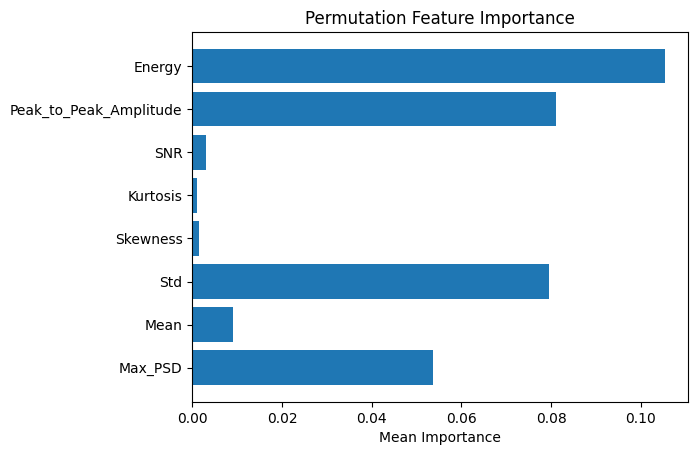

['/content/drive/MyDrive/Contest/perm_importance.pkl']

In [ ]:
# @title Cross-Validation


# Assuming aggregated_features and gmm_labels (after inversion) are available
k = 5  # Number of folds
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Perform cross-validation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf_model, waveform_features, gmm_labels, cv=skf, scoring='accuracy')

print(f"{k}-Fold Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

from sklearn.inspection import permutation_importance

# Fit the RandomForest model on the whole dataset for permutation importance
rf_model.fit(waveform_features, gmm_labels)

# Compute permutation importance
perm_importance = permutation_importance(rf_model, waveform_features, gmm_labels, n_repeats=30, random_state=42)

# Display feature importances
feature_names = ['Max_PSD', 'Mean', 'Std', 'Skewness', 'Kurtosis', 'SNR', 'Peak_to_Peak_Amplitude', 'Energy']
perm_importance_means = perm_importance.importances_mean

print("Permutation Importances:")
for feature, importance in zip(feature_names, perm_importance_means):
    print(f"{feature}: {importance:.4f}")

# Visualize permutation importances
plt.barh(feature_names, perm_importance_means)
plt.xlabel('Mean Importance')
plt.title('Permutation Feature Importance')
plt.show()

# Save
### Specify your location
joblib.dump(cv_scores, '/content/drive/MyDrive/Contest/cv_scores.pkl')
joblib.dump(perm_importance, '/content/drive/MyDrive/Contest/perm_importance.pkl')

In [ ]:
# @title Waveform Event times
# Extract spike times and cluster labels
spike_times_list = []  # To store spike times
assigned_clusters_list = []  # To store cluster labels

for filename in ncs_files:
    reader = NeuralynxIO(dirname=directory_path, include_filenames=[filename])
    seg = reader.read_segment()
    raw_data = np.array(seg.analogsignals[0]).flatten()

    # Filter and detect spikes
    filtered_data = bandpass_filter(raw_data, lowcut, highcut, sampling_rate)
    spike_indices = detect_spikes(filtered_data, threshold_factor)

    # Convert spike indices to times
    spike_times = spike_indices / sampling_rate
    spike_times_list.append(spike_times)

    # Predict cluster labels using the trained model
    features = extract_waveform_features(filtered_data, spike_indices)
    features = scaler.transform(features)  # Ensure features are standardized
    cluster_labels = classifier.predict(features)
    assigned_clusters_list.append(cluster_labels)

# Save spike times and cluster labels
results = {
    "Channel": [],
    "Time": [],
    "Cluster": []
}

for i, (spike_times, cluster_labels) in enumerate(zip(spike_times_list, assigned_clusters_list)):
    channel_name = ncs_files[i]
    for time, cluster in zip(spike_times, cluster_labels):
        results["Channel"].append(channel_name)
        results["Time"].append(time)
        results["Cluster"].append(cluster)

# Save results as a TSV file
### Specify your location
results_df = pd.DataFrame(results)
results_df.to_csv('/content/drive/MyDrive/Contest/waveform_event_clusters.tsv', sep='\t', index=False)


NameError: name 'scaler' is not defined

In [ ]:
# @title Waveform Event Times and Feature Extraction (Using Precomputed Features)

# This code performs spike detection, feature extraction, and label prediction in a single pass.

# Initialize lists to store results
results = {
    "Channel": [],
    "Time": [],
    "Cluster": [],
    "Max_PSD": [],
    "Mean": [],
    "Std": [],
    "Skewness": [],
    "Kurtosis": [],
    "SNR": [],
    "Peak_to_Peak_Amplitude": [],
    "Energy": []
}

for i, filename in enumerate(ncs_files):
    # Read the file and extract the raw signal data
    reader = NeuralynxIO(dirname=directory_path, include_filenames=[filename])
    seg = reader.read_segment()
    raw_data = np.array(seg.analogsignals[0]).flatten()

    # Filter the data and detect spikes
    filtered_data = bandpass_filter(raw_data, lowcut, highcut, sampling_rate)
    spike_indices = detect_spikes(filtered_data, threshold_factor)

    # Skip if no spikes detected
    if len(spike_indices) == 0:
        print(f"No spikes detected in {filename}. Skipping file.")
        continue

    # Calculate spike times
    spike_times = spike_indices / sampling_rate

    # Extract waveform features
    features = extract_waveform_features(filtered_data, spike_indices)
    features = scaler.transform(features)  # Standardize features

    # Predict clusters using the trained classifier
    cluster_labels = classifier.predict(features)

    # Populate results for each detected spike
    channel_name = ncs_files[i]
    for time, cluster, feature in zip(spike_times, cluster_labels, features):
        results["Channel"].append(channel_name)
        results["Time"].append(time)
        results["Cluster"].append(cluster)
        results["Max_PSD"].append(feature[0])
        results["Mean"].append(feature[1])
        results["Std"].append(feature[2])
        results["Skewness"].append(feature[3])
        results["Kurtosis"].append(feature[4])
        results["SNR"].append(feature[5])
        results["Peak_to_Peak_Amplitude"].append(feature[6])
        results["Energy"].append(feature[7])

# Create DataFrame and save results as TSV
### Specify your location
results_df_features = pd.DataFrame(results)
results_df_features.to_csv('/content/drive/MyDrive/Contest/waveform_event_clusters.tsv', sep='\t', index=False)
print("Results with waveform features saved.")


In [ ]:
# @title SUA and MUA Classification
# Define an appropriate threshold for SUA/MUA classification
threshold_snr = 1.0  # Adjust based on data analysis

# Check for the presence of 'SNR' column and classify clusters
if 'SNR' in results_df_features.columns:
    cluster_snr_mean = results_df_features.groupby('Cluster')['SNR'].mean()
    sua_criteria = cluster_snr_mean > threshold_snr
    cluster_classification = pd.DataFrame({
        'Cluster': sua_criteria.index,
        'Classification': ['SUA' if is_sua else 'MUA' for is_sua in sua_criteria]
    })

    # Save the SUA/MUA classification as a TSV file
    cluster_classification.to_csv('/content/drive/MyDrive/Contest/cluster_classification.tsv', sep='\t', index=False)
    print("SUA/MUA classification table saved.")
else:
    print("Error: 'SNR' column not found in results_df. Cannot perform SUA/MUA classification.")


SUA/MUA classification table saved.


In [ ]:
# @title Channel-Level Real/Simulated Classification


# Define classification criteria (for instance, if majority of spikes in a channel are labeled as "real")
# Assuming cluster label 0 corresponds to real and 1 to simulated after inversion

# Count the occurrences of each cluster label within each channel
channel_classification = results_df.groupby('Channel')['Cluster'].apply(lambda x: 'real' if (x == 0).sum() > (x == 1).sum() else 'simulated')

# Convert the series to a DataFrame for saving
channel_classification_df = channel_classification.reset_index()
channel_classification_df.columns = ['Channel', 'Classification']

# Save the channel classification as a TSV file
### Specify your location
channel_classification_df.to_csv('/content/drive/MyDrive/Contest/channel_classification.tsv', sep='\t', index=False)
print("Channel-level real/simulated classification table saved.")

# Display the entire table
display(channel_classification_df)

# Or, view the first few rows
print(channel_classification_df.head())


Channel-level real/simulated classification table saved.


,Channel,Classification
0,CSC1.Ncs,real
1,CSC10.Ncs,real
2,CSC100.Ncs,real
3,CSC101.Ncs,real
4,CSC102.Ncs,real
...,...,...
115,CSC95.Ncs,real
116,CSC96.Ncs,real
117,CSC97.Ncs,real
118,CSC98.Ncs,real


      Channel Classification
0    CSC1.Ncs           real
1   CSC10.Ncs           real
2  CSC100.Ncs           real
3  CSC101.Ncs           real
4  CSC102.Ncs           real


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=channel_classification_df)

https://docs.google.com/spreadsheets/d/1zcKYLNtovSIEuNoXxpUKbWE8Ej8yHOdsFcgZsRoXeoI#gid=0


/usr/local/lib/python3.10/dist-packages/google/colab/sheets.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return frame.applymap(_clean_val).replace({np.nan: None})


In [ ]:
# Generate classification report
print("Detailed Classification Report for CNN+LSTM Model:")
print(classification_report(all_labels, all_preds, target_names=['Real', 'Simulated']))


Detailed Classification Report for CNN+LSTM Model:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00    931439
   Simulated       0.98      0.99      0.98     74127

    accuracy                           1.00   1005566
   macro avg       0.99      1.00      0.99   1005566
weighted avg       1.00      1.00      1.00   1005566



Number of Real samples: 370063
Number of Simulated samples: 4657765


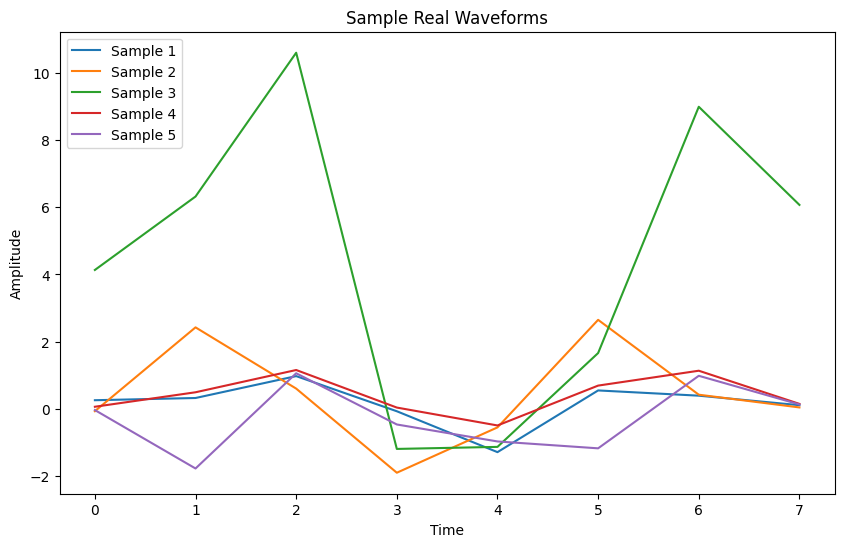

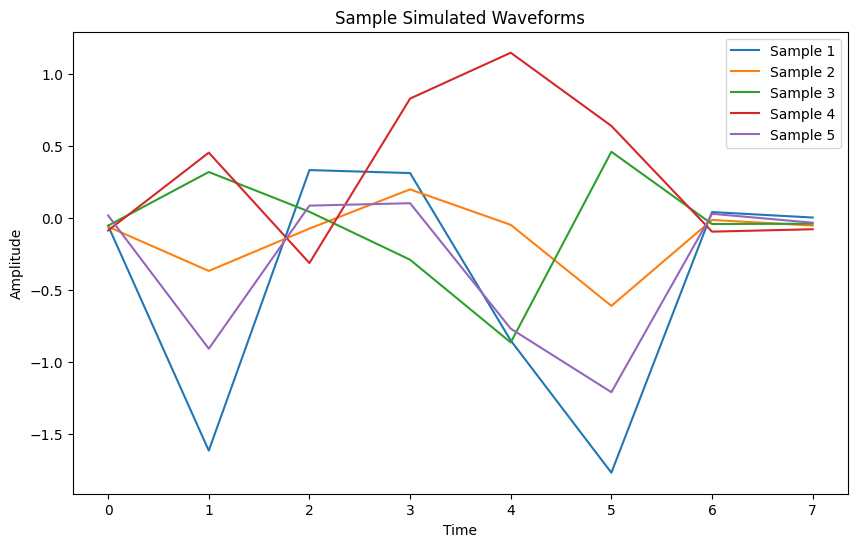

In [ ]:
# First, check the number of samples in each class
real_indices = np.where(gmm_labels == 1)[0]
simulated_indices = np.where(gmm_labels == 0)[0]

print(f"Number of Real samples: {len(real_indices)}")
print(f"Number of Simulated samples: {len(simulated_indices)}")

# Proceed only if there are samples in both classes
if len(real_indices) > 0 and len(simulated_indices) > 0:
    # Assuming 'waveforms' is an array containing the raw waveforms used for feature extraction
    # Ensure 'waveforms' is aligned with 'gmm_labels'

    # For example, if 'waveforms' is a list or array of waveforms corresponding to 'waveform_features'

    # Select 5 random samples from real and simulated classes
    num_samples = 5
    real_sample_indices = np.random.choice(real_indices, min(num_samples, len(real_indices)), replace=False)
    simulated_sample_indices = np.random.choice(simulated_indices, min(num_samples, len(simulated_indices)), replace=False)

    real_waveforms = [waveform_features[idx] for idx in real_sample_indices]
    simulated_waveforms = [waveform_features[idx] for idx in simulated_sample_indices]

    # Define plotting function
    def plot_waveforms(waveforms, title):
        plt.figure(figsize=(10, 6))
        for i, waveform in enumerate(waveforms):
            plt.plot(waveform, label=f'Sample {i+1}')
        plt.title(title)
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()

    # Plot real and simulated waveforms
    plot_waveforms(real_waveforms, "Sample Real Waveforms")
    plot_waveforms(simulated_waveforms, "Sample Simulated Waveforms")
else:
    print("Not enough samples in one of the classes to plot waveforms.")


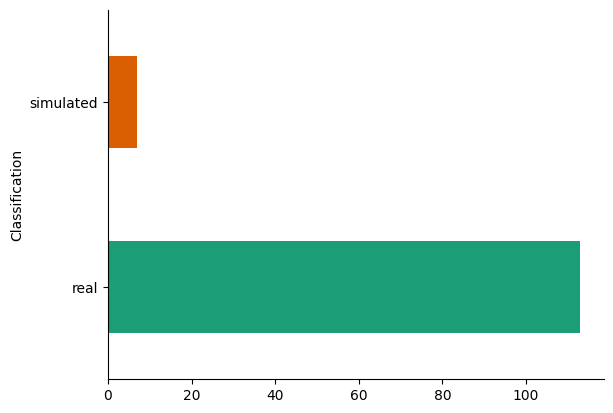

In [ ]:
# @title Classification

channel_classification_df.groupby('Classification').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

      Channel      Time  Cluster   Max_PSD      Mean       Std  Skewness  \
0  CSC120.Ncs  0.011406        0 -0.107403 -0.329358 -0.457515 -0.081574   
1  CSC120.Ncs  0.011437        0 -0.106645 -0.260799 -0.452272 -0.109526   
2  CSC120.Ncs  0.011469        0 -0.105995 -0.179835 -0.446178 -0.140062   
3  CSC120.Ncs  0.218875        0 -0.113605 -0.315271 -0.461797  0.299777   
4  CSC120.Ncs  0.218906        0 -0.113103 -0.295760 -0.459502  0.290704   

   Kurtosis       SNR  Peak_to_Peak_Amplitude    Energy  
0  0.061474 -1.057270               -0.315492 -0.089210  
1 -0.000237 -0.900497               -0.315492 -0.088867  
2 -0.067179 -0.717734               -0.315492 -0.088457  
3 -0.057882 -1.034689               -0.448822 -0.089571  
4 -0.083984 -0.988294               -0.448822 -0.089410  


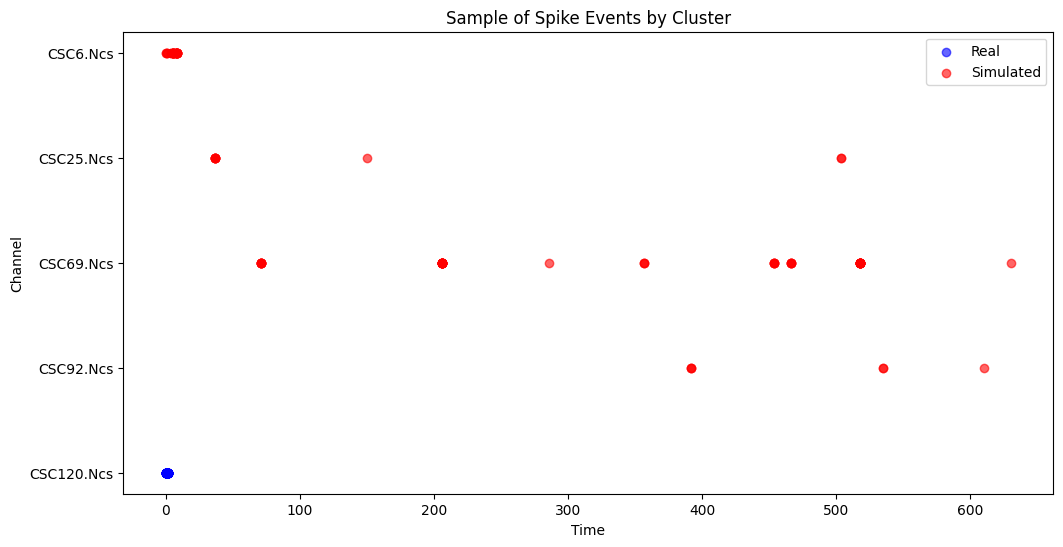

In [ ]:
### Specify your location
# Load the waveform event clusters file
waveform_event_clusters_df = pd.read_csv('/content/drive/MyDrive/Contest/waveform_event_clusters.tsv', sep='\t')

# Display the first few rows of the dataframe to inspect
print(waveform_event_clusters_df.head())

# Optional: Plot a sample of spike events for real and simulated clusters

# Sample of spike events for visualization
sample_real = waveform_event_clusters_df[waveform_event_clusters_df['Cluster'] == 0].head(100)
sample_simulated = waveform_event_clusters_df[waveform_event_clusters_df['Cluster'] == 1].head(100)

plt.figure(figsize=(12, 6))
plt.scatter(sample_real['Time'], sample_real['Channel'], color='blue', label='Real', alpha=0.6)
plt.scatter(sample_simulated['Time'], sample_simulated['Channel'], color='red', label='Simulated', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Channel')
plt.title('Sample of Spike Events by Cluster')
plt.legend()
plt.show()


In [ ]:
# @title OUTPUTS

# from neo.io import NeoHdf5IO  # If you want to use Neo-compatible formats

# Assuming `results` dictionary from the waveform event processing code provided earlier
results = {
    "Channel": [],  # e.g., CSC6.Ncs
    "Time": [],     # Spike event time in seconds
    "Cluster": []   # Cluster label (e.g., 0, 1)
}

# Populate the results dictionary
for i, filename in enumerate(ncs_files):
    # Read the file and extract the raw signal data
    reader = NeuralynxIO(dirname=directory_path, include_filenames=[filename])
    seg = reader.read_segment()
    raw_data = np.array(seg.analogsignals[0]).flatten()

    # Filter the data and detect spikes
    filtered_data = bandpass_filter(raw_data, lowcut, highcut, sampling_rate)
    spike_indices = detect_spikes(filtered_data, threshold_factor)
    spike_times = spike_indices / sampling_rate

    # Extract features and predict clusters
    features = extract_waveform_features(filtered_data, spike_indices)
    features = scaler.transform(features)
    cluster_labels = classifier.predict(features)

    # Append to results
    channel_name = ncs_files[i]
    for time, cluster in zip(spike_times, cluster_labels):
        results["Channel"].append(channel_name)
        results["Time"].append(time)
        results["Cluster"].append(cluster)

# Convert to DataFrame and save as a TSV
results_df = pd.DataFrame(results)
results_df.to_csv('waveform_event_clusters.tsv', sep='\t', index=False)
print("Waveform event times and clusters saved as 'waveform_event_clusters.tsv'.")

### Specify your location
joblib.dump(results_df, '/content/drive/MyDrive/Contest/waveform_event_clusters_df.pkl')

files.download('waveform_event_clusters.tsv')


['/content/drive/MyDrive/Contest/waveform_event_clusters_df.pkl']

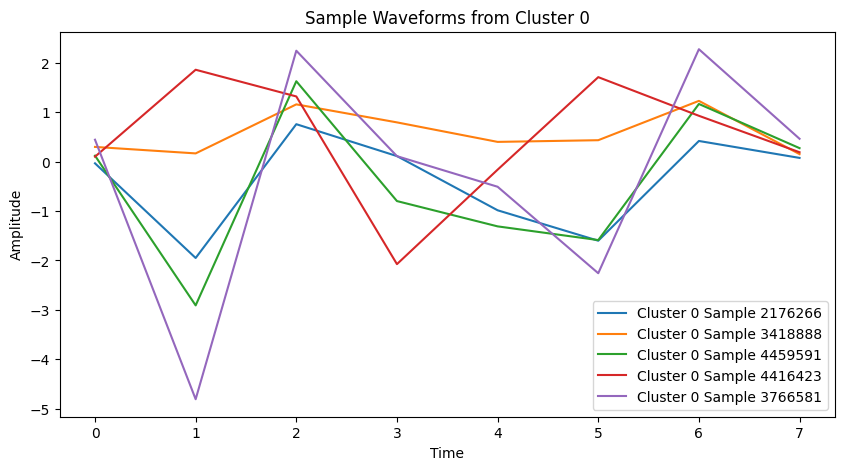

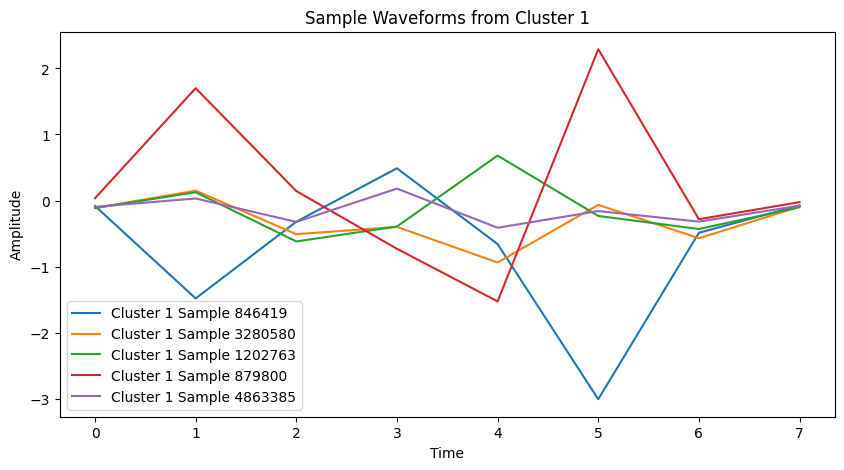

              SNR           Peak_to_Peak_Amplitude              Energy  \
             mean       std                   mean       std      mean   
Cluster                                                                  
0       -0.310098  1.345116               1.761672  2.589541  0.625909   
1        0.024638  0.963043              -0.139966  0.529634 -0.049729   

                   
              std  
Cluster            
0        3.622221  
1        0.058498  


In [ ]:
### Specify your location
# Assuming waveform_features contains your features and is already loaded
gmm = GaussianMixture(n_components=2, random_state=42)  # Adjust n_components if more clusters are suspected
gmm_labels = gmm.fit_predict(waveform_features)

# Randomly sample waveforms from each cluster
for cluster_id in np.unique(gmm_labels):
    sample_indices = np.random.choice(np.where(gmm_labels == cluster_id)[0], size=5, replace=False)
    plt.figure(figsize=(10, 5))
    for idx in sample_indices:
        plt.plot(waveform_features[idx], label=f'Cluster {cluster_id} Sample {idx}')
    plt.title(f'Sample Waveforms from Cluster {cluster_id}')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()

# Convert waveform_features to a DataFrame for easier analysis
features_df = pd.DataFrame(waveform_features, columns=['Max_PSD', 'Mean', 'Std', 'Skewness', 'Kurtosis', 'SNR', 'Peak_to_Peak_Amplitude', 'Energy'])
features_df['Cluster'] = gmm_labels

# Calculate summary statistics for each feature by cluster
cluster_summary = features_df.groupby('Cluster').agg({
    'SNR': ['mean', 'std'],
    'Peak_to_Peak_Amplitude': ['mean', 'std'],
    'Energy': ['mean', 'std']
})
print(cluster_summary)




In [ ]:
# Define labels based on analysis findings
single_unit_clusters = {
    0: "Single Unit",  # Based on observed characteristics, Cluster 0 is real neuronal activity
    1: "Noise"         # Based on observed characteristics, Cluster 1 is noise
}

# Save this as a TSV file for clarity and submission
cluster_label_df = pd.DataFrame(list(single_unit_clusters.items()), columns=["Cluster", "Label"])
cluster_label_df.to_csv('cluster_labels.tsv', sep='\t', index=False)
print("Cluster label table saved as 'cluster_labels.tsv'.")

### Specify your location
files.download('cluster_labels.tsv')

Cluster label table saved as 'cluster_labels.tsv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
### Specify your location
# Define path to save the results
save_path = '/content/drive/MyDrive/Contest/waveform_event_clusters.tsv'

# Initialize the results dictionary with additional features
results = {
    "Channel": [],
    "Time": [],
    "Cluster": [],
    "SNR": [],
    "Peak_to_Peak_Amplitude": [],
    "Energy": []
}

# Populate the results dictionary with waveform events and additional features
for i, filename in enumerate(ncs_files):
    # Read the file and extract raw data
    reader = NeuralynxIO(dirname=directory_path, include_filenames=[filename])
    seg = reader.read_segment()
    raw_data = np.array(seg.analogsignals[0]).flatten()

    # Filter and detect spikes
    filtered_data = bandpass_filter(raw_data, lowcut, highcut, sampling_rate)
    spike_indices = detect_spikes(filtered_data, threshold_factor)
    spike_times = spike_indices / sampling_rate

    # Extract waveform features
    features = extract_waveform_features(filtered_data, spike_indices)
    features = scaler.transform(features)
    cluster_labels = classifier.predict(features)

    # Append features to results
    channel_name = ncs_files[i]
    for time, cluster, feature in zip(spike_times, cluster_labels, features):
        results["Channel"].append(channel_name)
        results["Time"].append(time)
        results["Cluster"].append(cluster)
        results["SNR"].append(feature[5])  # Assuming SNR is at index 5
        results["Peak_to_Peak_Amplitude"].append(feature[6])  # Assuming Peak-to-Peak Amplitude is at index 6
        results["Energy"].append(feature[7])  # Assuming Energy is at index 7

# Convert to DataFrame and save as TSV
results_df = pd.DataFrame(results)
results_df.to_csv(save_path, sep='\t', index=False)
print(f"Waveform event times and clusters with additional features saved as '{save_path}'.")

# Load the updated file and check columns
waveform_event_clusters = pd.read_csv(save_path, sep='\t')
print("Updated columns in waveform_event_clusters:", waveform_event_clusters.columns)

### Specify your location
# Load and display the first few rows of the waveform_event_clusters.tsv file
waveform_event_clusters = pd.read_csv('/content/drive/MyDrive/Contest/waveform_event_clusters.tsv', sep='\t')
print(waveform_event_clusters)

### Specify your location
# Download the file to your local machine
files.download('/content/drive/MyDrive/Contest/waveform_event_clusters.tsv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Calculate mean SNR and Peak-to-Peak Amplitude per channel
channel_classification = {}
for channel, group in waveform_event_clusters.groupby('Channel'):
    mean_snr = group['SNR'].mean()
    mean_peak_to_peak = group['Peak_to_Peak_Amplitude'].mean()

    # Example threshold-based classification logic
    if mean_snr > 0 and mean_peak_to_peak > 0:  # Adjust criteria as needed
        channel_classification[channel] = "Real"
    else:
        channel_classification[channel] = "Simulated"

### Specify your location
# Convert to DataFrame and save as TSV
channel_classification_df = pd.DataFrame(list(channel_classification.items()), columns=["Channel", "Classification"])
channel_classification_df.to_csv('/content/drive/MyDrive/Contest/channel_classification.tsv', sep='\t', index=False)
print("Channel classification saved as 'channel_classification.tsv'.")

files.download('/content/drive/MyDrive/Contest/channel_classification.tsv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>